In [1]:
from activation_funcs import *
from error_funcs import *
from initializer import *
from optimizer import *

from Model import MyModel
from layers import *

import numpy as np
import matplotlib.pyplot as plt
import pickle

In [2]:
with open("data.pickle", "rb") as fr:
    data = pickle.load(fr)

1. 데이터 확인

In [3]:
type(data)

dict

In [4]:
data.keys()

dict_keys(['x_train', 'y_train', 'y_test', 'x_validation', 'x_test', 'y_validation'])

In [5]:
x_train = data['x_train']
y_train = data['y_train']
x_test = data['x_test']
y_test = data['y_test']
x_validation = data['x_validation']
y_validation = data['y_validation']

In [6]:
print(type(x_train))
print(x_train.shape)

print(type(y_train))
print(y_train.shape)

print(type(x_test))
print(x_test.shape)

print(type(y_test))
print(y_test.shape)

<class 'numpy.ndarray'>
(49000, 3, 32, 32)
<class 'numpy.ndarray'>
(49000,)
<class 'numpy.ndarray'>
(1000, 3, 32, 32)
<class 'numpy.ndarray'>
(1000,)


- 데이터 정규화 상태 확인

In [7]:
print(x_train.min())
print(x_train.max())

print(x_test.min())
print(x_test.max())

print(x_validation.min())
print(x_validation.max())

-2.2071382620689115
2.6225875967515537
-2.2071382620689115
2.6225875967515537
-2.2071382620689115
2.6225875967515537


In [8]:
from PIL import Image

img = x_train[5] # 3x32x32
img = img.transpose(1, 2, 0) # 32x32x3
img = ((img+3) / 6) * 255
img = Image.fromarray(img.astype('uint8'))
img.show()

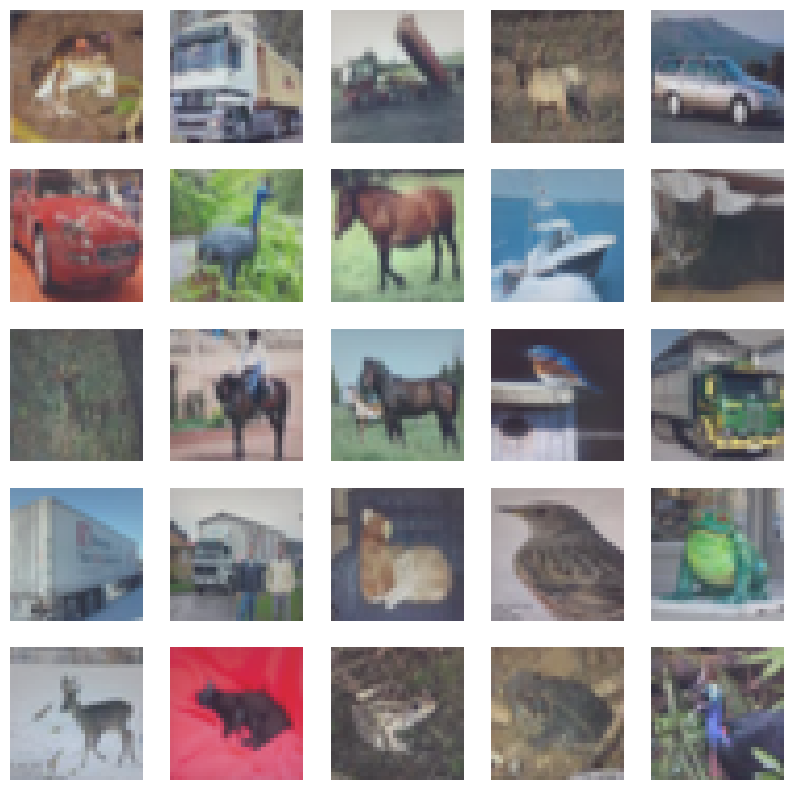

In [9]:
# 5x5 그리드로 이미지 확인
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i+1)
    img = x_train[i].transpose(1, 2, 0)
    img = ((img + 3) / 6) # 대략적인 복원
    plt.imshow(np.clip(img, 0, 1)) # 0~1 사이로 클리핑
    plt.axis('off')
plt.show()

- 데이터를 0~1 사이로 정규화

In [10]:
x_train = (x_train + 3) / 6
x_validation = (x_validation + 3) / 6
x_test = (x_test + 3) / 6

- 데이터 증강을 통해 훈련 데이터 추가 확보

In [12]:
from PIL import Image
augmented_x = []
for data in x_train:
    data = data.transpose(1, 2, 0) # 3x32x32 -> 32x32x3
    data_pil = Image.fromarray((data * 255).astype(np.uint8))

    if np.random.rand() > 0.5: # 절반 확률
        img_pil = img_pil.transpose(Image.FLIP_LEFT_RIGHT) # 좌우 반전
    
    # 무작위 이동
    pad = 4
    img_pil = Image.fromarray(np.pad(np.array(data_pil), ((pad, pad), (pad, pad), (0, 0)), mode='reflect'))
    w, h = img_pil.size
    top = np.random.randint(0, pad * 2)
    left = np.random.randint(0, pad * 2)
    img_pil = img_pil.crop((left, top, left + 32, top + 32))
    
    # 4. PIL -> NumPy 복원 (H, W, C -> C, H, W)
    final_img = np.array(img_pil).transpose(2, 0, 1) / 255.0
    augmented_x.append(final_img)

x_train = np.array(list(x_train) + augmented_x)

y_train = np.array(list(y_train) + list(y_train))

In [13]:
print(x_train.shape)
print(y_train.shape)

(98000, 3, 32, 32)
(98000,)


In [9]:
set(y_train)

{np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9)}

In [14]:
def one_hot_encoding(label, max_num=10):
    tmp = [0 for i in range(max_num)]
    tmp[int(label)] = 1
    return tmp

def one_hot_decoding(label):
    return label.index(1)

In [15]:
y_train = np.array([one_hot_encoding(i) for i in y_train])

2. 모델 설계 및 학습, 테스트

In [16]:
cnn_model = MyModel()

cnn_model.add_layer(Conv(filter_num=16, filter_channels=3, filter_height=3, filter_width=3, stride=1, pad=1, learning_rate=0.1)) # 3x32x32 
cnn_model.add_layer(BatchNormalization()) # 1
cnn_model.add_layer(Relu())
cnn_model.add_layer(Conv(filter_num=16, filter_channels=16, filter_height=3, filter_width=3, stride=1, pad=1, learning_rate=0.1)) # 3x32x32 
cnn_model.add_layer(BatchNormalization()) # 4
cnn_model.add_layer(Relu())
cnn_model.add_layer(Pooling(pool_h=2, pool_w=2, stride=2, pad=0)) # 16x16 -> (N, C, H, W) = (batch, 16, 16, 16)
cnn_model.add_layer(Conv(filter_num=16, filter_channels=16, filter_height=3, filter_width=3, stride=1, pad=1, learning_rate=0.1)) # 16x16
cnn_model.add_layer(BatchNormalization()) # 8
cnn_model.add_layer(Relu())
cnn_model.add_layer(Conv(filter_num=16, filter_channels=16, filter_height=3, filter_width=3, stride=1, pad=1, learning_rate=0.1)) # 16x16
cnn_model.add_layer(BatchNormalization()) # 11
cnn_model.add_layer(Relu())
cnn_model.add_layer(Pooling(pool_h=2, pool_w=2, stride=2, pad=0)) # 8x8 -> (N, C, H, W) = (batch, 16, 8, 8)
cnn_model.add_layer(Flatten())
cnn_model.add_layer(Affine(input_size=1024, output_size=512, learning_rate=0.1)) # 16x8x8=1024
cnn_model.add_layer(Relu())
cnn_model.add_layer(Affine(input_size=512, output_size=128, learning_rate=0.1))
cnn_model.add_layer(Relu())
cnn_model.add_layer(Affine(input_size=128, output_size=10, learning_rate=0.01))
cnn_model.add_layer(Softmax())

cnn_model.set_loss_func(func=CrossEntropyError())

In [17]:
# x_train_cnn = x_train.reshape(-1, 3, 32, 32)
# x_test_cnn = x_test.reshape(-1, 3, 32, 32)
cnn_model.load_data(data_kind='train', x=x_train, y=y_train)
cnn_model.data_batch_setting(setting_data='x_train', batch_size=100)
cnn_model.data_batch_setting(setting_data='y_train', batch_size=100)

In [18]:
epoch = 50

In [19]:
cnn_model.learn(epoch=epoch)

start epoch 1


KeyboardInterrupt: 

In [26]:
for i in [1, 4, 8, 11]:
    cnn_model.layer[i].train_flg = False

In [27]:
predict_labels = []
batch_size = 100
for i in range(0, len(x_test), batch_size):
    x_batch = x_test[i:i+batch_size]
    pred_raw = cnn_model.predict(x_batch)
    pred_label = np.argmax(pred_raw, axis=1)
    predict_labels.extend(pred_label)

predict_labels = np.array(predict_labels)
accuracy = np.sum(predict_labels == y_test) / len(y_test)
print(f"test accuracy: {accuracy:.4f}")

test accuracy: 0.7120


In [20]:
resnet_model = MyModel()

resnet_model.add_layer(Conv(filter_num=16, filter_channels=3, filter_height=3, filter_width=3, stride=1, pad=1, learning_rate=0.08))
resnet_model.add_layer(BatchNormalization()) # 1
resnet_model.add_layer(Relu())
resnet_model.add_layer(Pooling(pool_h=2, pool_w=2, stride=2, pad=0))
resnet_model.add_layer(ResidualBlock_With_Norm(filter_num=16, filter_height=3, filter_width=3, stride=1, pad=1, lr=0.08)) # 4
resnet_model.add_layer(Relu())
resnet_model.add_layer(ResidualBlock_With_Norm(filter_num=16, filter_height=3, filter_width=3, stride=1, pad=1, lr=0.08)) # 6
resnet_model.add_layer(Relu())
resnet_model.add_layer(Pooling(pool_h=2, pool_w=2, stride=2, pad=0))
resnet_model.add_layer(ResidualBlock_With_Norm(filter_num=16, filter_height=3, filter_width=3, stride=1, pad=1, lr=0.08)) # 9
resnet_model.add_layer(Relu())
resnet_model.add_layer(ResidualBlock_With_Norm(filter_num=16, filter_height=3, filter_width=3, stride=1, pad=1, lr=0.08)) # 11
resnet_model.add_layer(Relu())
resnet_model.add_layer(Flatten())
resnet_model.add_layer(Affine(input_size=1024, output_size=256, learning_rate=0.05)) # 16x8x8
resnet_model.add_layer(Relu())
resnet_model.add_layer(Dropout(dropout_ratio=0.5))
resnet_model.add_layer(Affine(input_size=256, output_size=10, learning_rate=0.05))
resnet_model.add_layer(Softmax())


resnet_model.set_loss_func(func=CrossEntropyError())

In [21]:
resnet_model.load_data(data_kind='train', x=x_train, y=y_train)
resnet_model.data_batch_setting(setting_data='x_train', batch_size=100)
resnet_model.data_batch_setting(setting_data='y_train', batch_size=100)

In [22]:
resnet_model.learn(epoch=epoch)

start epoch 1


KeyboardInterrupt: 

In [ ]:
for i in [1, 4, 6, 9, 11]:
    resnet_model.layer[i].train_flg = False
resnet_model.layer[16].train_flg = False

In [ ]:
predict_labels = []
batch_size = 100
for i in range(0, len(x_test), batch_size):
    x_batch = x_test[i:i+batch_size]
    pred_raw = resnet_model.predict(x_batch)
    pred_label = np.argmax(pred_raw, axis=1)
    predict_labels.extend(pred_label)

predict_labels = np.array(predict_labels)
accuracy = np.sum(predict_labels == y_test) / len(y_test)
print(f"test accuracy: {accuracy:.4f}")

test accuracy: 0.7090


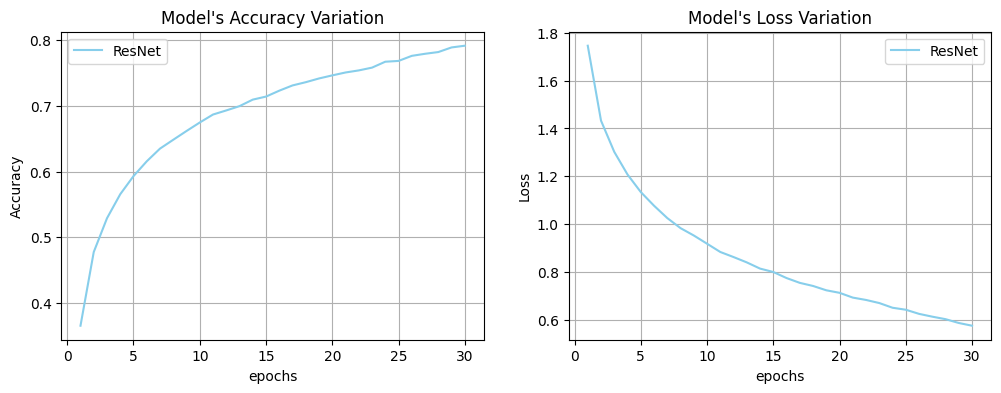

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
# ax1.plot([i+1 for i in range(15)], cnn_model.acc_log, label='CNN', color='green')
ax1.plot([i+1 for i in range(epoch)], resnet_model.acc_log, label='ResNet', color='skyblue')
ax1.set_title("Model's Accuracy Variation")
ax1.set_xlabel("epochs")
ax1.set_ylabel("Accuracy")
ax1.grid()
ax1.legend()

# ax2.plot([i+1 for i in range(15)], cnn_model.loss_log, label='CNN', color='green')
ax2.plot([i+1 for i in range(epoch)], resnet_model.loss_log, label='ResNet', color='skyblue')
ax2.set_title("Model's Loss Variation")
ax2.set_xlabel("epochs")
ax2.set_ylabel("Loss")
ax2.grid()
ax2.legend()

plt.show()